In [118]:
%matplotlib inline
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l


In [132]:
class KaggleHouse(d2l.DataModule):
    def __init__(self, batch_size, train=None, val=None):
        super().__init__()
        self.save_hyperparameters()
        if self.train is None:
            self.raw_train = pd.read_csv(d2l.download(
            d2l.DATA_URL + 'kaggle_house_pred_train.csv', self.root,
            sha1_hash='585e9cc93e70b39160e7921475f9bcd7d31219ce'))
            self.raw_val = pd.read_csv(d2l.download(
            d2l.DATA_URL + 'kaggle_house_pred_test.csv', self.root,
            sha1_hash='fa19780a7b011d9b009e8bff8e99922a8ee2eb90'))

In [133]:
data = KaggleHouse(batch_size=64)
print(data.raw_train.shape)
print(data.raw_val.shape)

(1460, 81)
(1459, 80)


In [134]:
print(data.raw_train.iloc[:4, [0, 1, 2, 3, -3, -2, -1]])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


In [135]:
@d2l.add_to_class(KaggleHouse)
def preprocess(self):
    label = "SalePrice"
    features = pd.concat(
        [self.raw_train.drop(columns=["Id", label]),
        self.raw_val.drop(columns=["Id"])]
    )

    numeric_features = features.dtypes[features.dtypes!="object"].index
    features[numeric_features] = features[numeric_features].apply(
        lambda x : (x - x.mean()) / x.std()
    )
    # for idx in numeric_features:
    #     features[idx] = features[idx].fillna(value=features[idx].mean())

    features = pd.get_dummies(features, dummy_na=True)

    self.train = features[:self.raw_train.shape[0]].copy()
    self.train[label] = self.raw_train[label] 
    self.val = features[self.raw_train.shape[0]:].copy()

In [136]:
data = KaggleHouse(batch_size=64)

In [137]:
data.preprocess()
data.train.shape

(1460, 331)

In [138]:
@d2l.add_to_class(KaggleHouse)
def get_dataloader(self, train):
    label = 'SalePrice'
    data = self.train if train else self.val
    if label not in data: return
    get_tensor = lambda x : torch.tensor(x.values.astype(float), dtype=torch.float32)
    tensors = (
        get_tensor(data.drop(columns=[label])), #X
        torch.log(get_tensor(data[label])).reshape(-1, 1) #Y
    )
    return self.get_tensorloader(tensors, train)

In [139]:
def k_fold_data(data, k):
    rets = []
    fold_size = data.train.shape[0] // k
    
    for j in range(k):
        idx = range(j*fold_size, (j+1)*fold_size)
        rets.append(KaggleHouse(data.batch_size, data.train.drop(index=idx), data.train.loc[idx]))
    return rets

In [140]:
def k_fold(trainer, data, k, model):
    val_loss, models = [], []

    for i, data_fold in enumerate(k_fold_data(data, k)):
        # model.board.yscale = 'log'
        if i!=0 : model.board.display = False
        trainer.fit(model, data_fold)
        val_loss.append(float(model.board.data['val_loss'][-1].y))
        models.append(model)

    print(f'average validation log mse = {sum(val_loss)/len(val_loss)}')
    return models


average validation log mse = nan


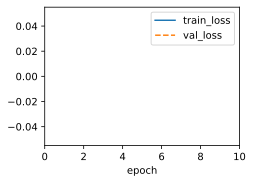

In [141]:
trainer = d2l.Trainer(max_epochs=10)
models = k_fold(trainer, data, k=5, model=d2l.LinearRegression(lr=0.005))

In [ ]:
preds = [model(torch.tensor(data.val.values.astype(float), dtype=torch.float32)) for model in models]
# Taking exponentiation of predictions in the logarithm scale
ensemble_preds = torch.exp(torch.cat(preds, 1)).mean(1)
submission = pd.DataFrame({'Id':data.raw_val.Id,
                           'SalePrice':ensemble_preds.detach().numpy()})
submission.to_csv('submission.csv', index=False)

In [ ]:
class MLP(d2l.Module):
    def __init__(self, num_hidden, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyLinear(num_hidden),
            nn.ReLU(),
            nn.LazyLinear(num_hidden),
            nn.ReLU(),
            nn.LazyLinear(1)
        )

    def forward(self, X):
        return self.net(X)
    
    def loss(self, y_hat, y):
        fn = nn.MSELoss()
        return fn(y_hat, y)
    
    def training_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=True)
        return l
    
    def validation_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=False)

    def configure_optimizers(self):
        return torch.optim.SGD(params=self.parameters(), lr=self.lr)

In [ ]:
models = k_fold(trainer, data, k=5, model=MLP(num_hidden=64, lr=0.003))


average validation log mse = nan
Error in callback <function _draw_all_if_interactive at 0x0000014716FE2200> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore can not be log-scaled.

ValueError: Data has no positive values, and therefore can not be log-scaled.

<Figure size 350x250 with 1 Axes>

### MLP hidden layer = 2 & hidden units = 32 & lr = 0.001
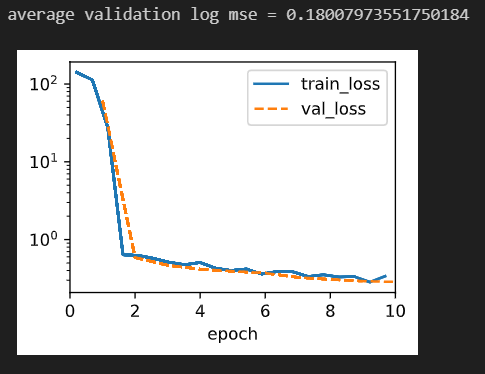

### MLP hidden layer = 2 & hidden units = 64 & lr = 0.003
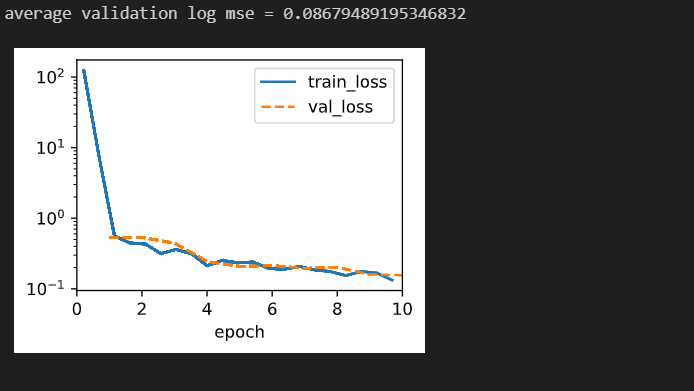

### MLP hidden layer = 2 & hidden units = 64 & lr = 0.003
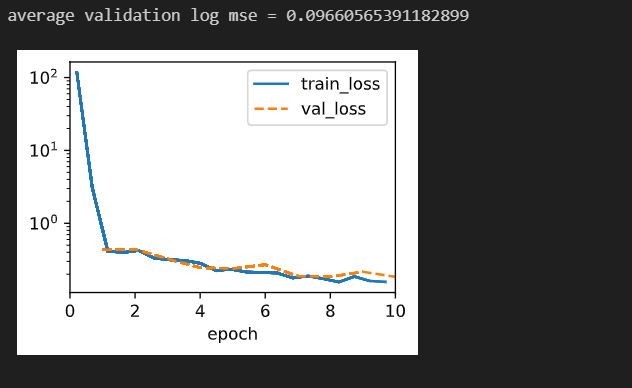

### MLP hidden layer = 2 & hidden units = 64 & lr = 0.003 & dropout = 0.5
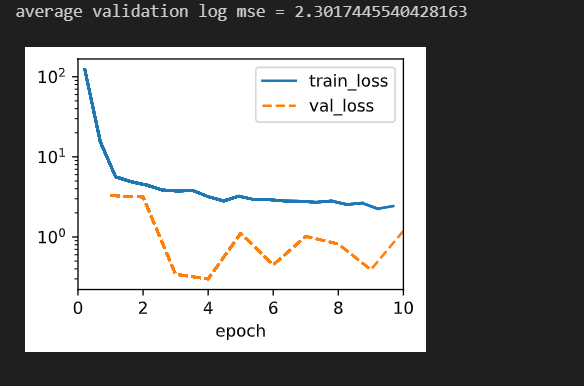